# Procurement Invoice Fraud Detection — Modeling

In [3]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

from src.data_processing import load_data, merge_data

In [4]:
invoices, labels, suppliers, departments, behaviour, splits = load_data()

In [5]:
print(invoices.shape)
print(labels.shape)
print(suppliers.shape)
print(departments.shape)
print(behaviour.shape)
print(splits.shape)

(300000, 10)
(300000, 5)
(2000, 6)
(50, 3)
(300000, 7)
(300000, 2)


In [6]:
from src.data_processing import merge_data

data = merge_data(
    invoices,
    labels,
    suppliers,
    departments,
    behaviour,
    splits
)

In [7]:
data.shape

(300000, 28)

In [8]:
y = data["is_fraud"]
y.value_counts()

is_fraud
0    233590
1     66410
Name: count, dtype: int64

In [9]:
features = [
    "invoice_date",
    "invoice_amount",
    "payment_terms",
    "invoice_type",
    "submission_hour",
    "supplier_country",
    "supplier_age_days",
    "supplier_risk_score",
    "avg_invoice_amount",
    "region",
    "annual_budget",
    "supplier_invoice_count_30d",
    "supplier_avg_amount_90d"
]

X = data[features].copy()

X.shape

(300000, 13)

In [10]:
X["invoice_month"] = X["invoice_date"].dt.month
X["invoice_day_of_week"] = X["invoice_date"].dt.dayofweek

X = X.drop(columns=["invoice_date"])
X.shape

(300000, 14)

In [11]:
train_mask = data["split"] == "train"
val_mask = data["split"] == "val"
test_mask = data["split"] == "test"

X_train = X[train_mask]
X_val = X[val_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

In [12]:
X_train.shape, X_val.shape, X_test.shape

((210000, 14), (30000, 14), (60000, 14))

In [13]:
categorical_features = [
    "payment_terms",
    "invoice_type",
    "supplier_country",
    "region"
]

numerical_features = [
    "invoice_amount",
    "submission_hour",
    "supplier_age_days",
    "supplier_risk_score",
    "avg_invoice_amount",
    "annual_budget",
    "supplier_invoice_count_30d",
    "supplier_avg_amount_90d",
    "invoice_month",
    "invoice_day_of_week"
]

len(categorical_features), len(numerical_features)

(4, 10)

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [15]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['invoice_amount','payment_terms','invoice_type',..., 'supplier_avg_amount_90d','invoice_month','invoice_day_of_week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default o

### Baseline Model Pipeline

The baseline model uses a scikit-learn `Pipeline` that combines data preprocessing with Logistic Regression. This ensures that the same preprocessing steps are automatically applied whenever the model is trained or used to make predictions.

The pipeline processes the input features in two groups:

- **Categorical features:** `payment_terms`, `invoice_type`, `supplier_country`, and `region` are processed using One-Hot Encoding. This converts the categorical values into numerical indicator columns that the model can understand. The four original categorical columns expand into **155 encoded features**.

- **Numerical features:** the 10 numerical variables are processed using `StandardScaler`. Scaling puts numerical features with very different units and ranges onto comparable scales, which is particularly useful for Logistic Regression.

After preprocessing, the original 14 input features become **165 model-ready features** in total:

**155 one-hot encoded categorical features + 10 scaled numerical features = 165 features**

These 165 features are then passed to the **Logistic Regression** model.

Logistic Regression is used as the first baseline model because it provides a relatively simple and interpretable starting point. Later models can be compared against this baseline to determine whether additional model complexity produces a meaningful improvement in fraud detection.

In [16]:
y_val_pred = baseline_model.predict(X_val)
y_val_pred[:20]

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [17]:
from sklearn.metrics import accuracy_score

val_accuracy = accuracy_score(y_val, y_val_pred)

val_accuracy

0.7776333333333333

In [18]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_val, y_val_pred)

array([[22984,   243],
       [ 6428,   345]])

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.78      0.99      0.87     23227
           1       0.59      0.05      0.09      6773

    accuracy                           0.78     30000
   macro avg       0.68      0.52      0.48     30000
weighted avg       0.74      0.78      0.70     30000



### Baseline Model Performance

The #1 baseline Logistic Regression achieved a validation accuracy of approximately **77.76%**. However, accuracy alone is misleading in this problem because the validation dataset is imbalanced: approximately 77% of the invoices are normal.

A model that predicted every invoice as normal would therefore already achieve roughly 77% accuracy without detecting any fraud.

The confusion matrix provides a clearer picture of the model's performance:

- **22,984** normal invoices were correctly classified as normal.
- **243** normal invoices were incorrectly flagged as fraudulent.
- **6,428** fraudulent invoices were incorrectly classified as normal.
- **345** fraudulent invoices were correctly detected.

For the fraud class (`1`), the model achieved:

- **Precision: 0.59** — approximately 59% of the invoices flagged as fraud were actually fraudulent.
- **Recall: 0.05** — the model detected only approximately 5% of all fraudulent invoices.
- **F1-score: 0.09** — the low score reflects the poor balance between fraud precision and recall.

The baseline model is therefore highly conservative: it rarely predicts fraud. Although its fraud alerts have moderate precision, it misses approximately 95% of the fraudulent invoices.

For a procurement audit system, detecting only 5% of fraud is insufficient. Therefore, subsequent modeling will focus on improving fraud recall while monitoring the trade-off with precision and the number of legitimate invoices unnecessarily sent for manual review.

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Fraud precision:", precision_score(y_val, y_val_pred))
print("Fraud recall:", recall_score(y_val, y_val_pred))
print("Fraud F1-score:", f1_score(y_val, y_val_pred))

Fraud precision: 0.5867346938775511
Fraud recall: 0.05093754613908165
Fraud F1-score: 0.09373726395870126


In [21]:
y_val_prob = baseline_model.predict_proba(X_val)[:, 1]

y_val_prob[:20]

array([0.1282552 , 0.1759856 , 0.26678842, 0.27739075, 0.26406379,
       0.67335468, 0.11644202, 0.12668481, 0.24861635, 0.20692863,
       0.31194807, 0.1290159 , 0.27347928, 0.3005067 , 0.46009074,
       0.18677667, 0.16354973, 0.29485681, 0.29109298, 0.26213391])

In [22]:
for threshold in [0.5, 0.4, 0.3, 0.2]:
    predictions = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, predictions)
    recall = recall_score(y_val, predictions)
    f1 = f1_score(y_val, predictions)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")
    print()

Threshold: 0.5
Precision: 0.587
Recall: 0.051
F1-score: 0.094

Threshold: 0.4
Precision: 0.490
Recall: 0.111
F1-score: 0.181

Threshold: 0.3
Precision: 0.403
Recall: 0.279
F1-score: 0.329

Threshold: 0.2
Precision: 0.286
Recall: 0.731
F1-score: 0.411



In [23]:
for threshold in [0.5, 0.4, 0.3, 0.2]:
    predictions = (y_val_prob >= threshold).astype(int)

    flagged = predictions.sum()
    flagged_percentage = flagged / len(predictions) * 100

    print(f"Threshold: {threshold}")
    print(f"Invoices flagged: {flagged}")
    print(f"Audit workload: {flagged_percentage:.1f}%")
    print()

Threshold: 0.5
Invoices flagged: 588
Audit workload: 2.0%

Threshold: 0.4
Invoices flagged: 1537
Audit workload: 5.1%

Threshold: 0.3
Invoices flagged: 4687
Audit workload: 15.6%

Threshold: 0.2
Invoices flagged: 17346
Audit workload: 57.8%



In [24]:
threshold_results = []

for threshold in np.arange(0.10, 0.51, 0.05):
    predictions = (y_val_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, predictions),
        "recall": recall_score(y_val, predictions),
        "f1": f1_score(y_val, predictions),
        "audit_workload": predictions.mean()
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,threshold,precision,recall,f1,audit_workload
0,0.10,0.223867,0.986860,0.364947,0.995233
1,0.15,0.240576,0.936660,0.382826,0.879000
2,0.20,0.285541,0.731286,0.410714,0.578200
3,0.25,0.346039,0.462424,0.395854,0.301700
4,0.30,0.402816,0.278754,0.329494,0.156233
5,0.35,0.461265,0.172302,0.250887,0.084333
6,0.40,0.489915,0.111177,0.181227,0.051233
7,0.45,0.535417,0.075890,0.132937,0.032000
8,0.50,0.586735,0.050938,0.093737,0.019600


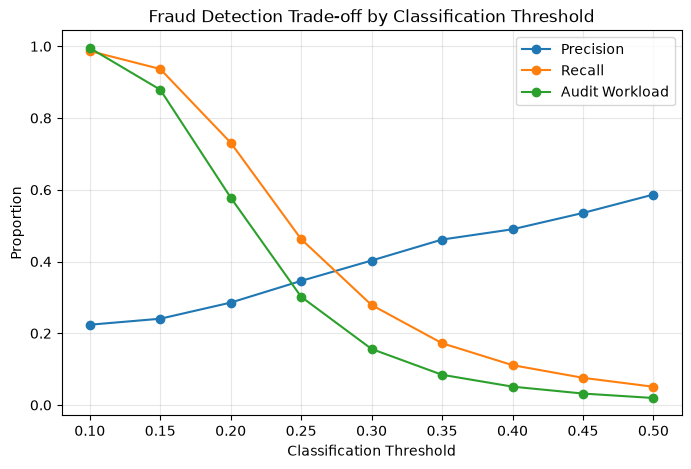

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(threshold_results["threshold"], threshold_results["precision"], marker="o", label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], marker="o", label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["audit_workload"], marker="o", label="Audit Workload")

plt.xlabel("Classification Threshold")
plt.ylabel("Proportion")
plt.title("Fraud Detection Trade-off by Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

 audit_capacity_pct  num_invoices_reviewed  implied_threshold   recall  precision
                1.0                    300           0.577599 0.030415   0.686667
                2.0                    600           0.497494 0.051823   0.585000
                5.0                   1500           0.402496 0.109110   0.492667
               10.0                   3000           0.335607 0.197549   0.446000
               15.0                   4500           0.303383 0.271962   0.409333
               20.0                   6000           0.280675 0.338550   0.382167
               25.0                   7500           0.263928 0.401742   0.362800
               30.0                   9000           0.250403 0.460210   0.346333


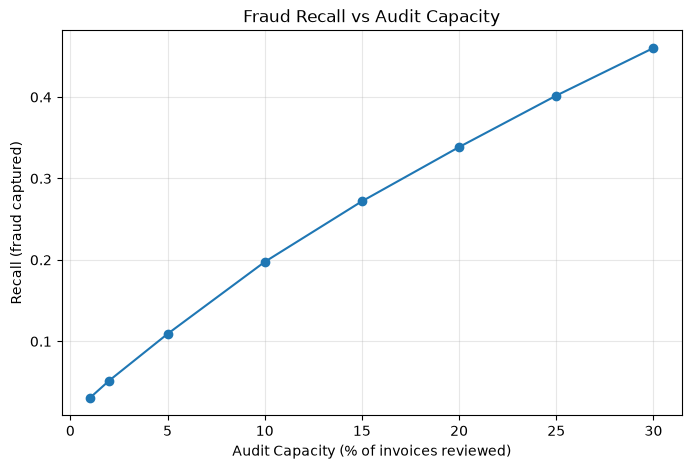

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Build capacity-indexed evaluation table ---

n_total = len(y_val)
total_fraud = y_val.sum()

# Sort indices by predicted fraud probability, descending
sorted_idx = np.argsort(-y_val_prob)
sorted_labels = np.array(y_val)[sorted_idx]
sorted_scores = np.array(y_val_prob)[sorted_idx]

capacity_levels = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

rows = []
for cap in capacity_levels:
    n_reviewed = int(np.ceil(cap * n_total))
    flagged_labels = sorted_labels[:n_reviewed]
    implied_threshold = sorted_scores[n_reviewed - 1]  # score at the cutoff

    tp = flagged_labels.sum()
    recall = tp / total_fraud
    precision = tp / n_reviewed

    rows.append({
        "audit_capacity_pct": cap * 100,
        "num_invoices_reviewed": n_reviewed,
        "implied_threshold": implied_threshold,
        "recall": recall,
        "precision": precision
    })

capacity_table = pd.DataFrame(rows)
print(capacity_table.to_string(index=False))

# --- Plot recall vs audit capacity ---
plt.figure(figsize=(8, 5))
plt.plot(capacity_table["audit_capacity_pct"], capacity_table["recall"], marker="o")
plt.xlabel("Audit Capacity (% of invoices reviewed)")
plt.ylabel("Recall (fraud captured)")
plt.title("Fraud Recall vs Audit Capacity")
plt.grid(True, alpha=0.3)
plt.show()

### Audit Capacity-Based Evaluation

A fixed classification threshold does not directly represent the operational constraints of a real audit team. In practice, an organization may only have enough resources to manually review a certain percentage of incoming invoices.

Therefore, the model is also evaluated using **audit capacity**. Validation invoices are ranked from highest to lowest predicted fraud score. For each audit capacity, only the highest-risk invoices that fit within that review budget are flagged for manual investigation.

Two main metrics are evaluated:

- **Recall:** the percentage of all fraudulent invoices captured within the reviewed group.
- **Precision:** the percentage of reviewed invoices that are actually fraudulent.

For the baseline Logistic Regression model, reviewing the highest-risk **10% of validation invoices (3,000 invoices)** captures approximately **19.8% of all fraud**, with a precision of approximately **44.6%**.

Increasing audit capacity captures more fraud, but also requires reviewing more invoices and gradually reduces precision. For example, increasing capacity to 30% captures approximately 46.0% of fraud, while precision decreases to approximately 34.6%.

This capacity-based evaluation provides a more operationally meaningful view of model performance than selecting an arbitrary probability threshold. It allows different models to be compared under the **same manual-review workload**.

The current Logistic Regression model serves as the baseline. No final audit capacity or probability threshold is selected at this stage. Alternative models will first be evaluated at the same capacity levels. After selecting the strongest model using the validation set, an appropriate operating point can be chosen based on the trade-off between fraud detection and audit workload.

The final model and operating policy will then be evaluated on the untouched test set.

In [27]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['invoice_amount','payment_terms','invoice_type',..., 'supplier_avg_amount_90d','invoice_month','invoice_day_of_week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default o

In [28]:
y_val_prob_rf = random_forest_model.predict_proba(X_val)[:, 1]

# reuse the exact same capacity-table code from before, just swap in y_val_prob_rf
sorted_idx = np.argsort(-y_val_prob_rf)
sorted_labels = np.array(y_val)[sorted_idx]
sorted_scores = np.array(y_val_prob_rf)[sorted_idx]

capacity_levels = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
n_total = len(y_val)
total_fraud = y_val.sum()

rows = []
for cap in capacity_levels:
    n_reviewed = int(np.ceil(cap * n_total))
    flagged_labels = sorted_labels[:n_reviewed]
    implied_threshold = sorted_scores[n_reviewed - 1]

    tp = flagged_labels.sum()
    recall = tp / total_fraud
    precision = tp / n_reviewed

    rows.append({
        "audit_capacity_pct": cap * 100,
        "num_invoices_reviewed": n_reviewed,
        "implied_threshold": implied_threshold,
        "recall": recall,
        "precision": precision
    })

rf_capacity_table = pd.DataFrame(rows)
print(rf_capacity_table.to_string(index=False))

 audit_capacity_pct  num_invoices_reviewed  implied_threshold   recall  precision
                1.0                    300           0.945672 0.043555   0.983333
                2.0                    600           0.929406 0.087258   0.985000
                5.0                   1500           0.892719 0.217629   0.982667
               10.0                   3000           0.830419 0.433929   0.979667
               15.0                   4500           0.758095 0.650524   0.979111
               20.0                   6000           0.652224 0.850583   0.960167
               25.0                   7500           0.481256 0.932821   0.842400
               30.0                   9000           0.367629 0.940647   0.707889


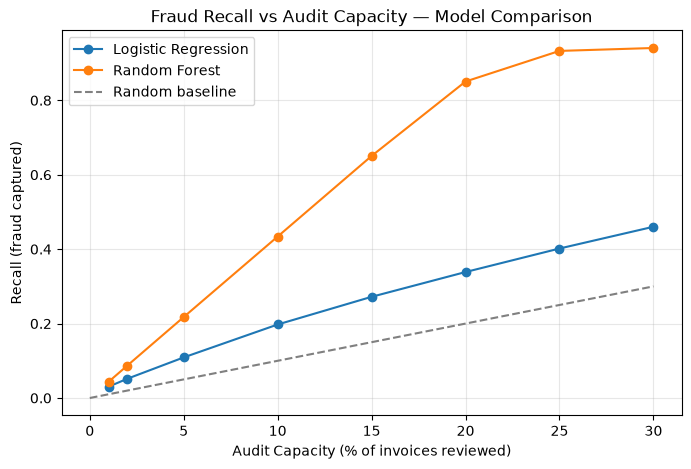

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(capacity_table["audit_capacity_pct"], capacity_table["recall"], marker="o", label="Logistic Regression")
plt.plot(rf_capacity_table["audit_capacity_pct"], rf_capacity_table["recall"], marker="o", label="Random Forest")
plt.plot([0, 30], [0, 0.30], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("Audit Capacity (% of invoices reviewed)")
plt.ylabel("Recall (fraud captured)")
plt.title("Fraud Recall vs Audit Capacity — Model Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
feature_names = random_forest_model[
    "preprocessor"
].get_feature_names_out()

feature_importances = random_forest_model[
    "model"
].feature_importances_

importance_table = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values(
    "importance",
    ascending=False
)

importance_table.head(20)

,feature,importance
155,numerical__invoice_amount,0.445929
162,numerical__supplier_avg_amount_90d,0.133064
159,numerical__avg_invoice_amount,0.111834
158,numerical__supplier_risk_score,0.059996
157,numerical__supplier_age_days,0.040765
156,numerical__submission_hour,0.018414
161,numerical__supplier_invoice_count_30d,0.018304
160,numerical__annual_budget,0.011871
163,numerical__invoice_month,0.009691
164,numerical__invoice_day_of_week,0.007736


In [31]:
# Build a deviation ratio and see if it separates fraud almost perfectly
X_val_check = X_val.copy()
X_val_check["amount_vs_avg_ratio"] = X_val_check["invoice_amount"] / X_val_check["avg_invoice_amount"]
X_val_check["amount_vs_supplier90d_ratio"] = X_val_check["invoice_amount"] / X_val_check["supplier_avg_amount_90d"]
X_val_check["is_fraud"] = y_val

# Look at the distribution split by fraud label
X_val_check.groupby("is_fraud")[["amount_vs_avg_ratio", "amount_vs_supplier90d_ratio"]].describe()

amount_vs_avg_ratio                                          \
                       count      mean       std       min       25%   
is_fraud                                                               
0                    23227.0  1.292906  0.716940  0.167097  0.801764   
1                     6773.0  0.853686  0.888014  0.092077  0.387404   

                                       amount_vs_supplier90d_ratio            \
               50%       75%       max                       count      mean   
is_fraud                                                                       
0         1.097667  1.567805  8.371740                     23227.0  1.081123   
1         0.492374  0.940887  8.634396                      6773.0  0.701182   

                                                                      
               std       min       25%       50%       75%       max  
is_fraud                                                              
0         0.578578  0.152485  0.674939  0.924631  1.310358  6.540388  
1         0.702524  0.065352  0.326602  0.408983  0.798941  6.256005

In [32]:
n_reviewed = int(0.10 * len(y_val))

top_10_idx = np.argsort(-y_val_prob_rf)[:n_reviewed]
top_10_original_idx = y_val.index[top_10_idx]

data.loc[top_10_original_idx, "fraud_type"].value_counts()

fraud_type
SPLIT             2191
INFLATED           374
GHOST_SUPPLIER     294
DOC_TAMPER         141
Name: count, dtype: int64

In [33]:
data.loc[y_val.index[y_val == 1], "fraud_type"].value_counts()

fraud_type
SPLIT             4316
GHOST_SUPPLIER    1224
INFLATED           553
NONE               446
DOC_TAMPER         226
DUPLICATE            8
Name: count, dtype: int64

 audit_capacity_pct  SPLIT_recall  GHOST_SUPPLIER_recall  INFLATED_recall  NONE_recall  DOC_TAMPER_recall  DUPLICATE_recall
                1.0      0.038230               0.020425         0.175407     0.000000           0.057522             0.000
                2.0      0.086654               0.025327         0.301989     0.000000           0.123894             0.000
                5.0      0.253244               0.062908         0.508137     0.000000           0.216814             0.000
               10.0      0.507646               0.240196         0.676311     0.000000           0.623894             0.000
               15.0      0.744671               0.491830         0.808318     0.022422           1.004425             0.000
               20.0      0.940686               0.856209         0.980108     0.266816           1.017699             0.125
               25.0      1.018999               1.015523         1.021700     2.383408           1.017699             0.125
        

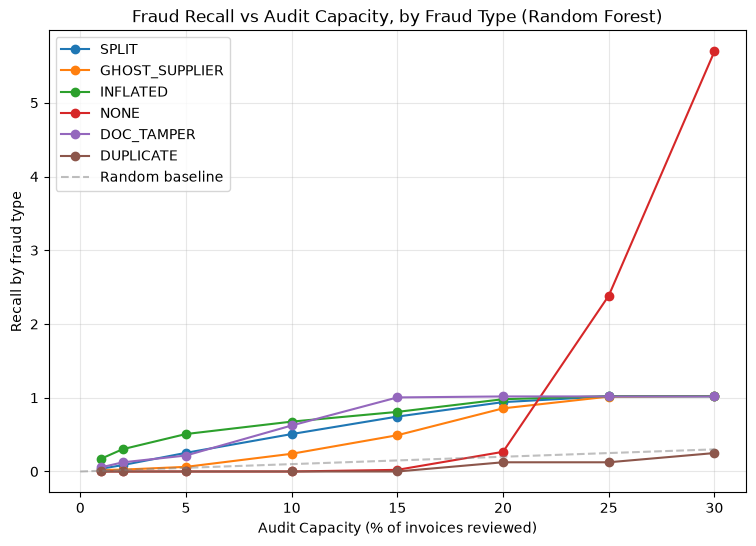

In [34]:
capacity_levels = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
n_total = len(y_val)

# Sort validation set by RF fraud probability, descending
sorted_idx = np.argsort(-y_val_prob_rf)
sorted_val_original_idx = y_val.index[sorted_idx]

# Pull fraud_type for the full validation set, aligned to y_val's index
val_fraud_type = data.loc[y_val.index, "fraud_type"]

# Total count per fraud type in the full validation set (denominator for recall)
total_by_type = val_fraud_type[y_val == 1].value_counts()

rows = []
for cap in capacity_levels:
    n_reviewed = int(np.ceil(cap * n_total))
    flagged_idx = sorted_val_original_idx[:n_reviewed]
    flagged_types = data.loc[flagged_idx, "fraud_type"]

    caught_by_type = flagged_types[flagged_types != "NONE"].value_counts()
    # include NONE and DUPLICATE explicitly too, since they matter
    caught_by_type = flagged_types.value_counts()

    row = {"audit_capacity_pct": cap * 100}
    for ftype in total_by_type.index:
        caught = caught_by_type.get(ftype, 0)
        total = total_by_type[ftype]
        row[f"{ftype}_recall"] = caught / total
    rows.append(row)

per_type_table = pd.DataFrame(rows)
print(per_type_table.to_string(index=False))

# Plot each fraud type's recall curve
plt.figure(figsize=(9, 6))
for ftype in total_by_type.index:
    plt.plot(per_type_table["audit_capacity_pct"], per_type_table[f"{ftype}_recall"], marker="o", label=ftype)
plt.plot([0, 30], [0, 0.30], linestyle="--", color="gray", alpha=0.5, label="Random baseline")
plt.xlabel("Audit Capacity (% of invoices reviewed)")
plt.ylabel("Recall by fraud type")
plt.title("Fraud Recall vs Audit Capacity, by Fraud Type (Random Forest)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [35]:
capacity_levels = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
rf_validation = pd.DataFrame({
    "is_fraud": y_val.values,
    "fraud_type": data.loc[y_val.index, "fraud_type"].values,
    "fraud_probability": y_val_prob_rf
})

rf_validation = rf_validation.sort_values(
    "fraud_probability",
    ascending=False
).reset_index(drop=True)

n_total = len(rf_validation)

# Denominator: total actual fraud count per type (only rows where is_fraud == 1)
total_by_type = rf_validation.loc[rf_validation["is_fraud"] == 1, "fraud_type"].value_counts()

rows = []
for cap in capacity_levels:
    n_reviewed = int(np.ceil(cap * n_total))
    flagged = rf_validation.iloc[:n_reviewed]

    # Numerator: only count rows that are BOTH flagged AND actually fraud
    caught_by_type = flagged.loc[flagged["is_fraud"] == 1, "fraud_type"].value_counts()

    row = {"audit_capacity_pct": cap * 100}
    for ftype in total_by_type.index:
        caught = caught_by_type.get(ftype, 0)
        total = total_by_type[ftype]
        row[f"{ftype}_recall"] = caught / total
    rows.append(row)

per_type_table = pd.DataFrame(rows)
print(per_type_table.to_string(index=False))

 audit_capacity_pct  SPLIT_recall  GHOST_SUPPLIER_recall  INFLATED_recall  NONE_recall  DOC_TAMPER_recall  DUPLICATE_recall
                1.0      0.037071               0.020425         0.175407     0.000000           0.057522             0.000
                2.0      0.084801               0.025327         0.300181     0.000000           0.123894             0.000
                5.0      0.248378               0.062092         0.500904     0.000000           0.216814             0.000
               10.0      0.497220               0.236111         0.663653     0.000000           0.606195             0.000
               15.0      0.729379               0.486111         0.793852     0.002242           0.986726             0.000
               20.0      0.920528               0.839052         0.962025     0.004484           1.000000             0.125
               25.0      0.997220               0.991830         1.000000     0.044843           1.000000             0.125
        

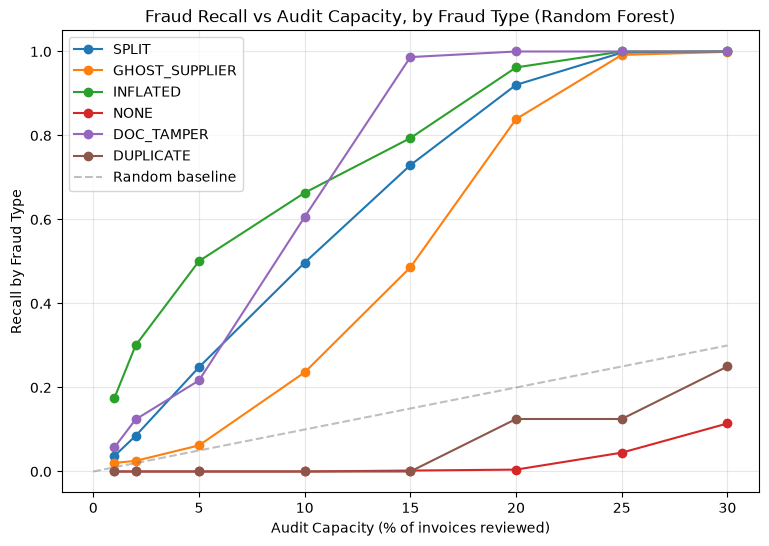

In [36]:
plt.figure(figsize=(9, 6))

for ftype in total_by_type.index:
    plt.plot(
        per_type_table["audit_capacity_pct"],
        per_type_table[f"{ftype}_recall"],
        marker="o",
        label=ftype
    )

plt.plot(
    [0, 30],
    [0, 0.30],
    linestyle="--",
    color="gray",
    alpha=0.5,
    label="Random baseline"
)

plt.xlabel("Audit Capacity (% of invoices reviewed)")
plt.ylabel("Recall by Fraud Type")
plt.title("Fraud Recall vs Audit Capacity, by Fraud Type (Random Forest)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [37]:
from sklearn.tree import DecisionTreeClassifier, export_text

top_features = [
    "invoice_amount",
    "supplier_avg_amount_90d",
    "avg_invoice_amount",
    "supplier_risk_score"
]

shallow_tree = DecisionTreeClassifier(
    max_depth=3,
    class_weight="balanced",
    random_state=42
)

shallow_tree.fit(X_train[top_features], y_train)

print(export_text(
    shallow_tree,
    feature_names=top_features
))

|--- invoice_amount <= 2482.10
|   |--- supplier_avg_amount_90d <= 3711.03
|   |   |--- invoice_amount <= 1416.61
|   |   |   |--- class: 1
|   |   |--- invoice_amount >  1416.61
|   |   |   |--- class: 0
|   |--- supplier_avg_amount_90d >  3711.03
|   |   |--- invoice_amount <= 1986.08
|   |   |   |--- class: 1
|   |   |--- invoice_amount >  1986.08
|   |   |   |--- class: 1
|--- invoice_amount >  2482.10
|   |--- invoice_amount <= 33997.07
|   |   |--- avg_invoice_amount <= 5466.94
|   |   |   |--- class: 0
|   |   |--- avg_invoice_amount >  5466.94
|   |   |   |--- class: 0
|   |--- invoice_amount >  33997.07
|   |   |--- invoice_amount <= 115178.86
|   |   |   |--- class: 1
|   |   |--- invoice_amount >  115178.86
|   |   |   |--- class: 1



In [38]:
from sklearn.metrics import classification_report

y_pred_shallow = shallow_tree.predict(X_val[top_features])

print(classification_report(y_val, y_pred_shallow))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89     23227
           1       0.65      0.49      0.56      6773

    accuracy                           0.83     30000
   macro avg       0.76      0.71      0.72     30000
weighted avg       0.81      0.83      0.82     30000



In [39]:
# Check what identifier columns are available for building supplier-relationship features
print([col for col in data.columns if "supplier" in col.lower() or "department" in col.lower() or "id" in col.lower()])

['invoice_id', 'supplier_id', 'department_id', 'supplier_country', 'supplier_age_days', 'supplier_risk_score', 'supplier_invoice_count_30d', 'supplier_avg_amount_90d']


In [44]:
# Sort by date to build backward-looking (no leakage) relationship features
data_sorted = data.sort_values("invoice_date").copy()

# 1. Invoice frequency ratio: recent activity relative to how long the supplier has existed
data_sorted["invoice_frequency_ratio"] = (
    data_sorted["supplier_invoice_count_30d"] / (data_sorted["supplier_age_days"] + 1)
)

# 2. Binary flag for "new" supplier — explicit cutoff, since the risk is likely non-linear
data_sorted["is_new_supplier"] = (data_sorted["supplier_age_days"] <= 90).astype(int)

# 3. Is this the supplier's first-ever invoice to this specific department?
data_sorted["is_first_invoice_to_department"] = (
    data_sorted.groupby(["supplier_id", "department_id"]).cumcount() == 0
).astype(int)

# 4. Log-transform supplier age (low value for RF, harmless to include)
data_sorted["log_supplier_age_days"] = np.log1p(data_sorted["supplier_age_days"])

# Merge these new columns back onto the original `data` using invoice_id, to preserve original row order
new_features = data_sorted[[
    "invoice_id",
    "invoice_frequency_ratio",
    "is_new_supplier",
    "is_first_invoice_to_department",
    "log_supplier_age_days"
]]

data = data.merge(new_features, on="invoice_id", how="left")

data[["invoice_frequency_ratio", "is_new_supplier", "is_first_invoice_to_department", "log_supplier_age_days"]].describe()

,invoice_frequency_ratio,is_new_supplier,is_first_invoice_to_department,log_supplier_age_days
count,300000.000000,300000.000000,300000.000000,300000.000000
mean,0.029387,0.059093,0.316660,7.203899
std,0.063701,0.235800,0.465174,1.315395
min,0.000200,0.000000,0.000000,3.433987
25%,0.003417,0.000000,0.000000,6.690842
50%,0.005663,0.000000,0.000000,7.716015
75%,0.015748,0.000000,1.000000,8.196988
max,0.742857,1.000000,1.000000,8.517193


In [45]:
train_mask = data["split"] == "train"
val_mask = data["split"] == "val"
test_mask = data["split"] == "test"

y = data["is_fraud"]

In [46]:
features = [
    "invoice_date",
    "invoice_amount",
    "payment_terms",
    "invoice_type",
    "submission_hour",
    "supplier_country",
    "supplier_age_days",
    "supplier_risk_score",
    "avg_invoice_amount",
    "region",
    "annual_budget",
    "supplier_invoice_count_30d",
    "supplier_avg_amount_90d",
    "invoice_frequency_ratio",
    "is_new_supplier",
    "is_first_invoice_to_department",
    "log_supplier_age_days"
]

X = data[features].copy()
X.shape

(300000, 17)

In [47]:
X["invoice_month"] = X["invoice_date"].dt.month
X["invoice_day_of_week"] = X["invoice_date"].dt.dayofweek

X = X.drop(columns=["invoice_date"])
X.shape

(300000, 18)

In [48]:
X_train = X[train_mask]
X_val = X[val_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

In [49]:
X_train.shape, X_val.shape, X_test.shape

((210000, 18), (30000, 18), (60000, 18))

In [50]:
categorical_features = [
    "payment_terms",
    "invoice_type",
    "supplier_country",
    "region"
]

numerical_features = [
    "invoice_amount",
    "submission_hour",
    "supplier_age_days",
    "supplier_risk_score",
    "avg_invoice_amount",
    "annual_budget",
    "supplier_invoice_count_30d",
    "supplier_avg_amount_90d",
    "invoice_month",
    "invoice_day_of_week",
    "invoice_frequency_ratio",
    "is_new_supplier",
    "is_first_invoice_to_department",
    "log_supplier_age_days"
]

len(categorical_features), len(numerical_features)

(4, 14)

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [52]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['invoice_amount','payment_terms','invoice_type',..., 'log_supplier_age_days','invoice_month','invoice_day_of_week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of 

In [53]:
y_val_prob_rf = random_forest_model.predict_proba(X_val)[:, 1]

capacity_levels = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
rf_validation = pd.DataFrame({
    "is_fraud": y_val.values,
    "fraud_type": data.loc[y_val.index, "fraud_type"].values,
    "fraud_probability": y_val_prob_rf
})

rf_validation = rf_validation.sort_values(
    "fraud_probability",
    ascending=False
).reset_index(drop=True)

n_total = len(rf_validation)
total_by_type = rf_validation.loc[rf_validation["is_fraud"] == 1, "fraud_type"].value_counts()

rows = []
for cap in capacity_levels:
    n_reviewed = int(np.ceil(cap * n_total))
    flagged = rf_validation.iloc[:n_reviewed]
    caught_by_type = flagged.loc[flagged["is_fraud"] == 1, "fraud_type"].value_counts()

    row = {"audit_capacity_pct": cap * 100}
    for ftype in total_by_type.index:
        caught = caught_by_type.get(ftype, 0)
        total = total_by_type[ftype]
        row[f"{ftype}_recall"] = caught / total
    rows.append(row)

per_type_table_v2 = pd.DataFrame(rows)
print(per_type_table_v2.to_string(index=False))

 audit_capacity_pct  SPLIT_recall  GHOST_SUPPLIER_recall  INFLATED_recall  NONE_recall  DOC_TAMPER_recall  DUPLICATE_recall
                1.0      0.041474               0.024510         0.121157     0.000000           0.079646             0.000
                2.0      0.091288               0.043301         0.198915     0.000000           0.128319             0.000
                5.0      0.240037               0.131536         0.414105     0.000000           0.199115             0.000
               10.0      0.463624               0.378268         0.640145     0.000000           0.548673             0.000
               15.0      0.686515               0.651144         0.766727     0.002242           0.964602             0.000
               20.0      0.897127               0.923203         0.954792     0.006726           1.000000             0.125
               25.0      0.993744               0.997549         1.000000     0.040359           1.000000             0.125
        

In [54]:
feature_names = random_forest_model["preprocessor"].get_feature_names_out()
feature_importances = random_forest_model["model"].feature_importances_

importance_table = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values("importance", ascending=False)

importance_table.head(20)

,feature,importance
155,numerical__invoice_amount,0.420949
162,numerical__supplier_avg_amount_90d,0.127826
159,numerical__avg_invoice_amount,0.107426
158,numerical__supplier_risk_score,0.054335
157,numerical__supplier_age_days,0.034539
168,numerical__log_supplier_age_days,0.034172
165,numerical__invoice_frequency_ratio,0.023606
156,numerical__submission_hour,0.018000
161,numerical__supplier_invoice_count_30d,0.015379
160,numerical__annual_budget,0.011729


In [55]:
capacity_results = []

total_fraud = rf_validation["is_fraud"].sum()

for cap in capacity_levels:
    n_reviewed = int(np.ceil(cap * len(rf_validation)))
    flagged = rf_validation.iloc[:n_reviewed]

    fraud_caught = flagged["is_fraud"].sum()
    fraud_recall = fraud_caught / total_fraud
    fraud_precision = fraud_caught / n_reviewed

    capacity_results.append({
        "audit_capacity_pct": cap * 100,
        "invoices_reviewed": n_reviewed,
        "fraud_caught": fraud_caught,
        "fraud_recall": fraud_recall,
        "fraud_precision": fraud_precision
    })

capacity_table = pd.DataFrame(capacity_results)

print(capacity_table.to_string(index=False))

 audit_capacity_pct  invoices_reviewed  fraud_caught  fraud_recall  fraud_precision
                1.0                300           294      0.043408         0.980000
                2.0                600           586      0.086520         0.976667
                5.0               1500          1471      0.217186         0.980667
               10.0               3000          2942      0.434372         0.980667
               15.0               4500          4403      0.650081         0.978444
               20.0               6000          5760      0.850436         0.960000
               25.0               7500          6308      0.931345         0.841067
               30.0               9000          6364      0.939613         0.707111


### Final audit capacity selection

An audit capacity of 20% was selected based on validation-set performance. At this operating point, the model reviews 6,000 of 30,000 validation invoices and captures approximately 85.0% of fraudulent invoices, while 96.0% of reviewed invoices are fraudulent.

The move from 15% to 20% capacity remains highly productive: 1,500 additional reviews identify 1,357 additional fraudulent invoices, while precision decreases only modestly from 97.8% to 96.0%.

Beyond 20%, marginal returns deteriorate substantially. Increasing capacity from 20% to 25% requires another 1,500 reviews but identifies only 548 additional fraudulent invoices, while precision falls from 96.0% to 84.1%. At 30% capacity, recall increases only slightly further to 94.0%, while precision falls to 70.7%.

Therefore, 20% is selected as the final operating point, balancing fraud capture against audit workload and false-positive burden. This decision is based solely on validation data and is fixed before evaluation on the untouched test set.

In [56]:
# Final, one-time test-set evaluation at the locked 20% audit capacity
# The model is NOT retrained — using the already-fitted random_forest_model

y_test_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

test_validation = pd.DataFrame({
    "is_fraud": y_test.values,
    "fraud_type": data.loc[y_test.index, "fraud_type"].values,
    "fraud_probability": y_test_prob_rf
})

test_validation = test_validation.sort_values(
    "fraud_probability",
    ascending=False
).reset_index(drop=True)

n_total_test = len(test_validation)
n_reviewed_test = int(np.ceil(0.20 * n_total_test))

flagged_test = test_validation.iloc[:n_reviewed_test]

total_fraud_test = test_validation["is_fraud"].sum()
fraud_caught_test = flagged_test["is_fraud"].sum()

test_recall = fraud_caught_test / total_fraud_test
test_precision = fraud_caught_test / n_reviewed_test

print("=== Final Test-Set Evaluation @ 20% Audit Capacity ===")
print(f"Invoices reviewed: {n_reviewed_test} of {n_total_test}")
print(f"Fraud caught: {fraud_caught_test} of {total_fraud_test}")
print(f"Recall: {test_recall:.4f}")
print(f"Precision: {test_precision:.4f}")

=== Final Test-Set Evaluation @ 20% Audit Capacity ===
Invoices reviewed: 12000 of 60000
Fraud caught: 11495 of 13510
Recall: 0.8509
Precision: 0.9579


In [57]:
# Per-fraud-type breakdown at the same locked 20% capacity, for completeness
total_by_type_test = test_validation.loc[test_validation["is_fraud"] == 1, "fraud_type"].value_counts()
caught_by_type_test = flagged_test.loc[flagged_test["is_fraud"] == 1, "fraud_type"].value_counts()

test_type_breakdown = pd.DataFrame({
    "total_fraud": total_by_type_test,
    "fraud_caught": caught_by_type_test.reindex(total_by_type_test.index, fill_value=0)
})
test_type_breakdown["recall"] = test_type_breakdown["fraud_caught"] / test_type_breakdown["total_fraud"]

print(test_type_breakdown)

                total_fraud  fraud_caught    recall
fraud_type                                         
SPLIT                  8504          7689  0.904163
GHOST_SUPPLIER         2489          2258  0.907192
INFLATED               1110          1053  0.948649
NONE                    903             2  0.002215
DOC_TAMPER              492           492  1.000000
DUPLICATE                12             1  0.083333


### Test-Set Generalization

The finalized model — Random Forest with the engineered supplier-relationship features, evaluated at the locked 20% audit capacity — was applied once to the untouched test set (60,000 invoices).

**Test-set results:** 12,000 invoices reviewed, capturing 85.09% recall at 95.79% precision.

**Validation-set results (for comparison):** 85.0% recall at 96.0% precision.

The test-set performance closely matches the validation-set performance, with differences of less than 0.3 percentage points in both recall and precision. This indicates the model generalizes well and that the 20% audit capacity decision, made using only validation data, is a stable operating point rather than an artifact of the validation split.

The per-fraud-type breakdown on the test set also mirrors the validation-set pattern: `DOC_TAMPER`, `INFLATED`, `GHOST_SUPPLIER`, and `SPLIT` are all captured at rates above 90% (SPLIT being barely above 90%), while `NONE`-type fraud remains almost entirely undetected (0.2% recall), confirming this as a structural limitation of the current feature set rather than a validation-set-specific weakness. `DUPLICATE` fraud has too few cases (12 in the test set) to draw a reliable conclusion.

**Conclusion:** the model, feature set, and 20% audit capacity are finalized based on this evaluation. No further tuning is performed on test-set results.